# Análise dos resultados do modelo estocástico (TRAIL/WALK, MTZ/EXP)

Resultados em `stochastic-results-model/` no padrão:
`experiment-{alpha}-{model}-{model_type}-{use_preprocessing}`

**Objetivo:**
1. Comparar versões com e sem pré-processamento
2. Comparar todas as abordagens: menor gap, melhor bound, menor runtime

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_experiment_folder_model,
    parse_experiment_name_model,
    export_model_config_to_latex,
    instance_sort_key,
    load_all_instance_data,
)

BASE_MODEL = Path("stochastic-results-model")
INSTANCE_FOLDERS = ["instances/simulated-alto-santo", "instances/simulated-limoeiro"]
ALPHA = 0.8
EXPORT_LATEX = True

if not BASE_MODEL.exists():
    raise FileNotFoundError(f"Pasta {BASE_MODEL} não encontrada.")

In [2]:
raw = parse_experiment_folder_model(BASE_MODEL)
records = [r for _, r in raw]
df_raw = pd.DataFrame(records)

params = [parse_experiment_name_model(r["experiment"]) for _, r in raw]
if params:
    for k in params[0].keys():
        df_raw[k] = [p.get(k) for p in params]

df_raw["LB"] = pd.to_numeric(df_raw["LB"], errors="coerce")
df_raw["UB"] = pd.to_numeric(df_raw["UB"], errors="coerce")
invalid_lb = df_raw["LB"] <= -1e+100
df_raw.loc[invalid_lb, "LB"] = 0
df_raw.loc[invalid_lb, "gap_pct"] = np.where(
    df_raw.loc[invalid_lb, "UB"] > 0, 100.0, 0.0
)

df_raw["gap_pct"] = pd.to_numeric(df_raw["gap_pct"], errors="coerce")
df_raw["config"] = (
    df_raw["model"] + "-" + df_raw["model_type"] + "-"
    + df_raw["use_preprocessing"].astype(str)
)

df_all = df_raw[df_raw["alpha"] == ALPHA].copy().reset_index(drop=True)

df_all["city"] = df_all["instance_name"].apply(lambda x: "-".join(x.split("-")[:-2]))
df_all["map_size"] = df_all["instance_name"].apply(
    lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0
)

print(f"Total bruto: {len(df_raw)}")
print(f"Total com alpha={ALPHA}: {len(df_all)}")
print(f"Configurações: {sorted(df_all['config'].unique())}")
print(f"Instâncias: {df_all['instance_name'].nunique()}")
df_all.head()

Total bruto: 3123
Total com alpha=0.8: 528
Configurações: ['EXP-TRAIL-0', 'EXP-TRAIL-1', 'EXP-WALK-0', 'EXP-WALK-1', 'MTZ-TRAIL-0', 'MTZ-TRAIL-1', 'MTZ-WALK-0', 'MTZ-WALK-1', 'TRAIL-EXP-0', 'TRAIL-EXP-1', 'TRAIL-MTZ-0', 'TRAIL-MTZ-1', 'WALK-EXP-0', 'WALK-EXP-1', 'WALK-MTZ-0', 'WALK-MTZ-1']
Instâncias: 36


,instance_name,attended_s0,attended_per_scenario,attended_avg,N,M,B,S,Alpha,LB,...,Runtime,gap_pct,experiment,alpha,model,model_type,use_preprocessing,config,city,map_size
0,alto-santo-500-5,34,"[34, 23, 28, 27, 27, 19, 22, 20, 21, 23, 24, 2...",18.117647,117,336,52,50,0.8,83.72,...,9.32948,0.0,experiment-0.8-EXP-TRAIL-0,0.8,EXP,TRAIL,0,EXP-TRAIL-0,alto-santo,500
1,alto-santo-500-6,37,"[37, 12, 12, 11, 14, 18, 12, 19, 19, 23, 23, 2...",17.980392,117,336,52,50,0.8,189.82,...,10.02970,0.0,experiment-0.8-EXP-TRAIL-0,0.8,EXP,TRAIL,0,EXP-TRAIL-0,alto-santo,500
2,alto-santo-1000-5,0,[],0.000000,179,524,84,50,0.8,0.00,...,3600.16000,100.0,experiment-0.8-EXP-TRAIL-0,0.8,EXP,TRAIL,0,EXP-TRAIL-0,alto-santo,1000
3,alto-santo-500-1,0,[],0.000000,117,336,52,50,0.8,0.00,...,3600.77000,100.0,experiment-0.8-EXP-TRAIL-0,0.8,EXP,TRAIL,0,EXP-TRAIL-0,alto-santo,500
4,alto-santo-1000-2,0,[],0.000000,179,524,84,50,0.8,0.00,...,3600.18000,100.0,experiment-0.8-EXP-TRAIL-0,0.8,EXP,TRAIL,0,EXP-TRAIL-0,alto-santo,1000


## 1. Comparação: com vs sem pré-processamento

Agrupamos por `use_preprocessing` (0 ou 1), independentemente da formulação (TRAIL/WALK × MTZ/EXP), para avaliar o impacto do pré-processamento no gap, bound e runtime.

In [3]:
prep_agg = df_all.groupby("use_preprocessing").agg(
    LB_medio=("LB", "mean"),
    UB_medio=("UB", "mean"),
    gap_medio=("gap_pct", "mean"),
    gap_std=("gap_pct", "std"),
    gap_max=("gap_pct", "max"),
    n_optimal=("gap_pct", lambda x: (x == 0).sum()),
    runtime_medio=("Runtime", "mean"),
    runtime_std=("Runtime", "std"),
    attended_s0_medio=("attended_s0", "mean"),
    n_results=("LB", "count"),
).reset_index()

prep_agg["use_preprocessing"] = prep_agg["use_preprocessing"].map({0: "Sem prep (0)", 1: "Com prep (1)"})
print("Comparação: Pré-processamento")
display(prep_agg)

Comparação: Pré-processamento


,use_preprocessing,LB_medio,UB_medio,gap_medio,gap_std,gap_max,n_optimal,runtime_medio,runtime_std,attended_s0_medio,n_results
0,Sem prep (0),30.423152,4.545455e+98,78.099597,29.919313,100.0,8,1271.271459,1502.276646,8.666667,264
1,Com prep (1),32.879812,4.545455e+98,76.739046,29.738495,100.0,7,1494.766881,1561.310573,8.492424,264


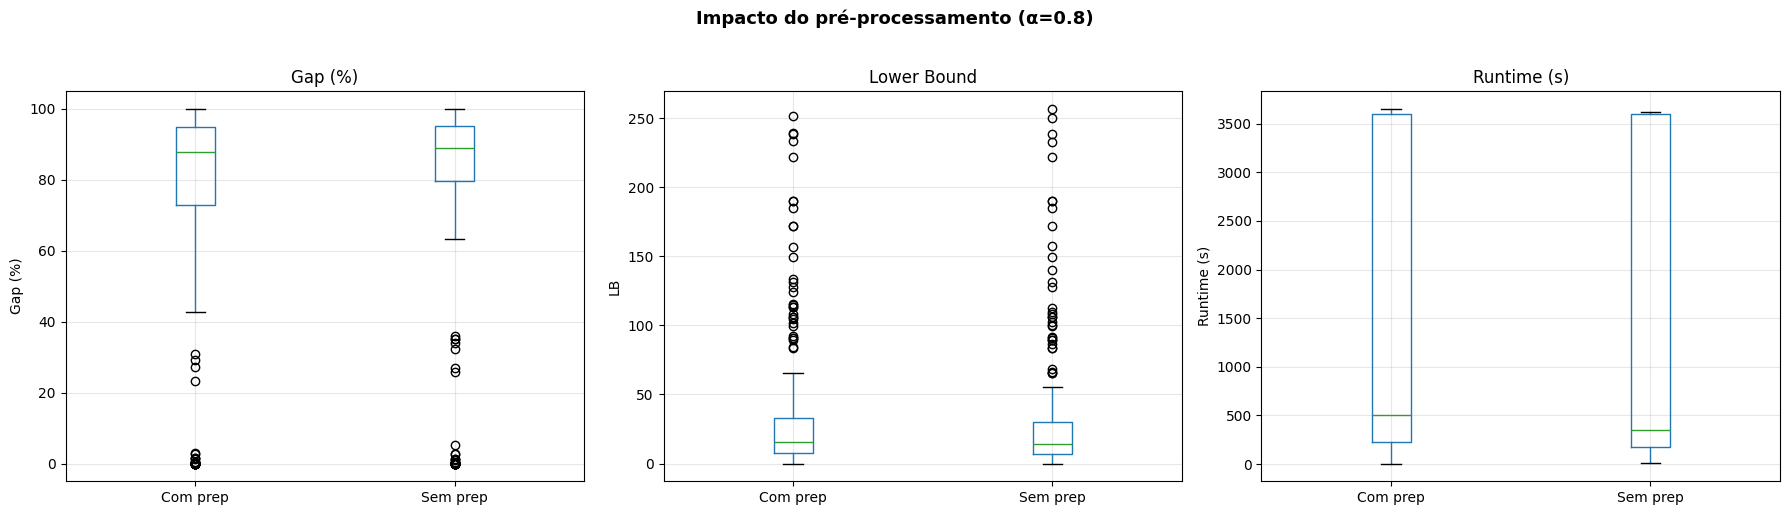

In [4]:
df_all["prep_label"] = df_all["use_preprocessing"].map({0: "Sem prep", 1: "Com prep"})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_all.boxplot(column="gap_pct", by="prep_label", ax=axes[0])
axes[0].set_title("Gap (%)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Gap (%)")

df_all.boxplot(column="LB", by="prep_label", ax=axes[1])
axes[1].set_title("Lower Bound")
axes[1].set_xlabel("")
axes[1].set_ylabel("LB")

df_all.boxplot(column="Runtime", by="prep_label", ax=axes[2])
axes[2].set_title("Runtime (s)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Runtime (s)")

plt.suptitle(f"Impacto do pré-processamento (α={ALPHA})", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
prep_inst = df_all.groupby(["instance_name", "use_preprocessing"]).agg(
    LB=("LB", "mean"),
    gap_pct=("gap_pct", "mean"),
    Runtime=("Runtime", "mean"),
).reset_index()

p0 = prep_inst[prep_inst["use_preprocessing"] == 0].set_index("instance_name")
p1 = prep_inst[prep_inst["use_preprocessing"] == 1].set_index("instance_name")
common = p0.index.intersection(p1.index)

n_lb_better = (p1.loc[common, "LB"] >= p0.loc[common, "LB"]).sum()
n_gap_better = (p1.loc[common, "gap_pct"] <= p0.loc[common, "gap_pct"]).sum()
n_rt_better = (p1.loc[common, "Runtime"] <= p0.loc[common, "Runtime"]).sum()

print(f"Instâncias comparáveis: {len(common)}")
print(f"  Com prep tem LB ≥ sem prep:      {n_lb_better}/{len(common)}")
print(f"  Com prep tem gap ≤ sem prep:      {n_gap_better}/{len(common)}")
print(f"  Com prep tem runtime ≤ sem prep:  {n_rt_better}/{len(common)}")

Instâncias comparáveis: 36
  Com prep tem LB ≥ sem prep:      23/36
  Com prep tem gap ≤ sem prep:      23/36
  Com prep tem runtime ≤ sem prep:  10/36


## 2. Comparação de todas as abordagens

Comparamos as 8 configurações (TRAIL/WALK × MTZ/EXP × prep 0/1) em termos de:
- **Menor gap médio**
- **Melhor bound (maior LB)**
- **Menor runtime**

In [6]:
config_agg = df_all.groupby("config").agg(
    LB_medio=("LB", "mean"),
    UB_medio=("UB", "mean"),
    gap_medio=("gap_pct", "mean"),
    gap_max=("gap_pct", "max"),
    n_optimal=("gap_pct", lambda x: (x == 0).sum()),
    runtime_medio=("Runtime", "mean"),
    runtime_min=("Runtime", "min"),
    runtime_max=("Runtime", "max"),
    attended_s0_medio=("attended_s0", "mean"),
    n_instances=("instance_name", "nunique"),
).reset_index()

display(config_agg.sort_values("gap_medio"))

,config,LB_medio,UB_medio,gap_medio,gap_max,n_optimal,runtime_medio,runtime_min,runtime_max,attended_s0_medio,n_instances
5,MTZ-TRAIL-1,116.813778,1.550346e+02,17.039580,82.326818,2,2680.034778,230.97000,3610.760,31.083333,36
4,MTZ-TRAIL-0,111.961000,1.562039e+02,19.500644,89.785788,3,2046.192389,256.40500,3601.540,28.000000,36
0,EXP-TRAIL-0,31.952667,1.558664e+02,74.522211,100.000000,5,3103.595002,7.87592,3601.830,12.888889,36
1,EXP-TRAIL-1,31.605569,1.551849e+02,79.722073,100.000000,5,3171.614060,5.16671,3601.600,10.833333,36
13,WALK-EXP-1,19.194152,1.580743e+02,85.386402,96.484429,0,466.054403,73.86350,3603.340,3.833333,36
15,WALK-MTZ-1,19.194152,1.580743e+02,85.386402,96.484429,0,469.429339,73.28220,3654.620,3.833333,36
11,TRAIL-MTZ-1,19.194152,1.580743e+02,85.386402,96.484429,0,464.575922,72.80720,3602.860,3.833333,36
9,TRAIL-EXP-1,19.194152,1.580743e+02,85.386402,96.484429,0,467.529717,72.24480,3606.350,3.833333,36
10,TRAIL-MTZ-0,15.423667,1.597699e+02,88.951229,100.000000,0,304.927217,92.24080,997.429,4.194444,36
8,TRAIL-EXP-0,15.423667,1.597699e+02,88.951229,100.000000,0,306.818072,92.96760,886.648,4.194444,36


In [7]:
best_gap = config_agg.loc[config_agg["gap_medio"].idxmin()]
best_lb = config_agg.loc[config_agg["LB_medio"].idxmax()]
best_rt = config_agg.loc[config_agg["runtime_medio"].idxmin()]

print(f"{'='*60}")
print(f"RESUMO — MELHORES ABORDAGENS (α={ALPHA})")
print(f"{'='*60}")
print(f"")
print(f"Menor gap médio:    {best_gap['config']}")
print(f"  gap = {best_gap['gap_medio']:.4f}%, LB = {best_gap['LB_medio']:.2f}, runtime = {best_gap['runtime_medio']:.2f}s")
print(f"")
print(f"Melhor bound (LB):  {best_lb['config']}")
print(f"  LB = {best_lb['LB_medio']:.2f}, gap = {best_lb['gap_medio']:.4f}%, runtime = {best_lb['runtime_medio']:.2f}s")
print(f"")
print(f"Menor runtime:      {best_rt['config']}")
print(f"  runtime = {best_rt['runtime_medio']:.2f}s, gap = {best_rt['gap_medio']:.4f}%, LB = {best_rt['LB_medio']:.2f}")
print(f"{'='*60}")

RESUMO — MELHORES ABORDAGENS (α=0.8)

Menor gap médio:    MTZ-TRAIL-1
  gap = 17.0396%, LB = 116.81, runtime = 2680.03s

Melhor bound (LB):  MTZ-TRAIL-1
  LB = 116.81, gap = 17.0396%, runtime = 2680.03s

Menor runtime:      WALK-EXP-0
  runtime = 285.93s, gap = 88.9512%, LB = 15.42


In [8]:
idx_best_lb = df_all.groupby("instance_name")["LB"].idxmax()
idx_best_gap = df_all.groupby("instance_name")["gap_pct"].idxmin()
idx_best_rt = df_all.groupby("instance_name")["Runtime"].idxmin()

wins_lb = df_all.loc[idx_best_lb].groupby("config").size().sort_values(ascending=False)
wins_gap = df_all.loc[idx_best_gap].groupby("config").size().sort_values(ascending=False)
wins_rt = df_all.loc[idx_best_rt].groupby("config").size().sort_values(ascending=False)

print("Vitórias por instância (qual config venceu em mais instâncias):")
print(f"\n  Melhor LB:")
for cfg, n in wins_lb.items():
    print(f"    {cfg}: {n}")
print(f"\n  Menor gap:")
for cfg, n in wins_gap.items():
    print(f"    {cfg}: {n}")
print(f"\n  Menor runtime:")
for cfg, n in wins_rt.items():
    print(f"    {cfg}: {n}")

Vitórias por instância (qual config venceu em mais instâncias):

  Melhor LB:
    MTZ-TRAIL-0: 16
    MTZ-TRAIL-1: 12
    EXP-TRAIL-0: 5
    EXP-TRAIL-1: 3

  Menor gap:
    MTZ-TRAIL-0: 15
    MTZ-TRAIL-1: 13
    EXP-TRAIL-0: 5
    EXP-TRAIL-1: 3

  Menor runtime:
    EXP-TRAIL-0: 5
    WALK-EXP-0: 5
    TRAIL-MTZ-0: 4
    MTZ-WALK-0: 4
    EXP-WALK-1: 3
    EXP-TRAIL-1: 2
    TRAIL-MTZ-1: 2
    EXP-WALK-0: 2
    TRAIL-EXP-1: 2
    TRAIL-EXP-0: 2
    WALK-EXP-1: 2
    MTZ-WALK-1: 1
    WALK-MTZ-0: 1
    WALK-MTZ-1: 1


/tmp/ipykernel_29383/2679075223.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=configs_sorted, patch_artist=True)
/tmp/ipykernel_29383/2679075223.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=configs_sorted, patch_artist=True)
/tmp/ipykernel_29383/2679075223.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=configs_sorted, patch_artist=True)


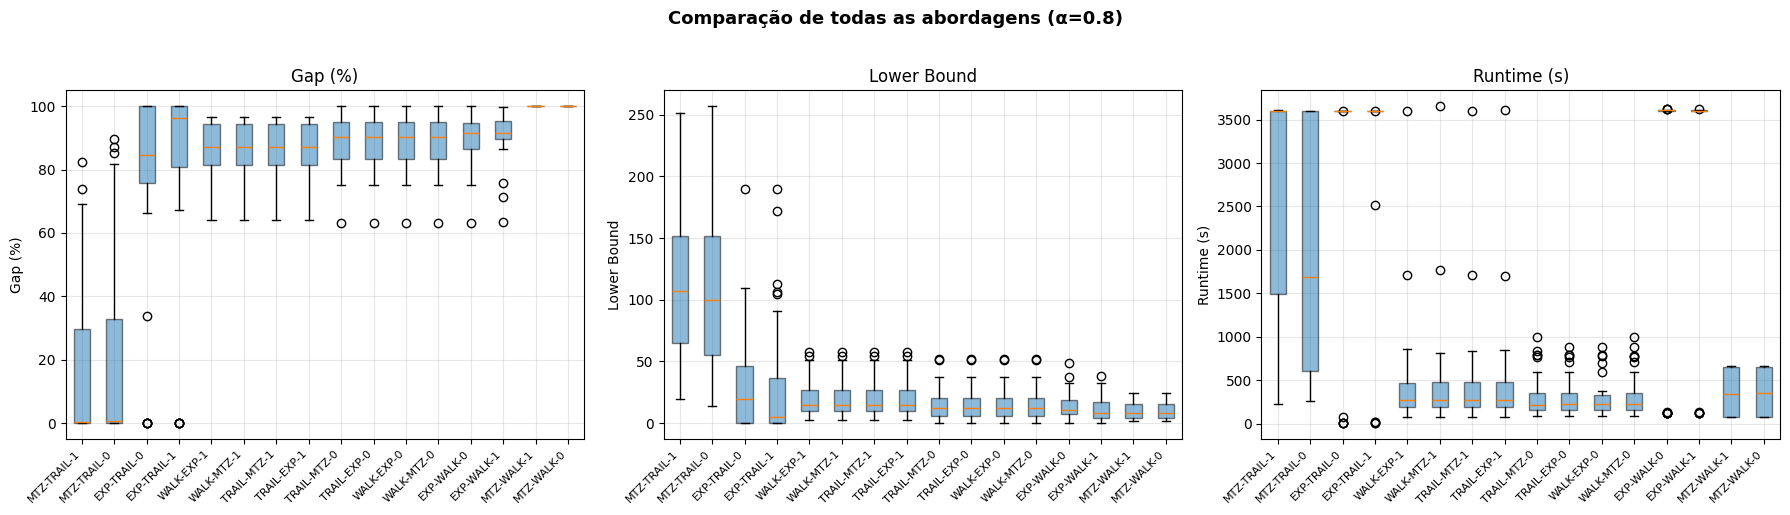

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs_sorted = config_agg.sort_values("gap_medio")["config"].tolist()

for i, (metric, title, ascending) in enumerate([
    ("gap_pct", "Gap (%)", True),
    ("LB", "Lower Bound", False),
    ("Runtime", "Runtime (s)", True),
]):
    ax = axes[i]
    data = [df_all[df_all["config"] == c][metric].values for c in configs_sorted]
    bp = ax.boxplot(data, labels=configs_sorted, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("C0")
        patch.set_alpha(0.5)
    ax.set_xticklabels(configs_sorted, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(title)

plt.suptitle(f"Comparação de todas as abordagens (α={ALPHA})",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Preview da MESMA tabela que será exportada por export_config_to_latex
# (linhas, colunas, precisão e cores idênticas ao .tex correspondente).
best_config_name = "EXP-WALK-1"
best_exp_name = f"experiment-0.8-{best_config_name}"

df_preview = df_all[df_all["experiment"] == best_exp_name].copy()
df_preview = df_preview.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))

table_preview = df_preview.rename(columns={
    "N": "|V|", "M": "|A|", "B": "|B|",
    "attended_s0": "Attended Blocks",
    "gap_pct": "gap (%)",
    "Gurobi_Nodes": "#B&B Nodes",
    "Lazy_cuts": "Lazy Cuts",
    "Runtime": "Exec. Time (s)",
    "instance_name": "Instance",
})
cols = ["Instance", "|V|", "|A|", "|B|", "S", "Alpha", "Attended Blocks",
        "LB", "UB", "gap (%)", "#B&B Nodes", "Lazy Cuts", "Exec. Time (s)"]
table_preview = table_preview[[c for c in cols if c in table_preview.columns]]

# Formatação à la _fmt_num do export (vírgula como decimal, mesma precisão).
def _fmt_br(decimals: int):
    def _f(x):
        if x is None or (isinstance(x, float) and pd.isna(x)):
            return "-"
        if isinstance(x, (int, np.integer)) and decimals == 0:
            return str(int(x))
        return f"{float(x):.{decimals}f}".replace(".", ",")
    return _f

fmt = {
    "Alpha": _fmt_br(1),
    "LB": _fmt_br(2), "UB": _fmt_br(2),
    "gap (%)": _fmt_br(2), "Exec. Time (s)": _fmt_br(2),
}

# Mesma regra de cor de linha do _model_stochastic_rowcolor_latex,
# adaptada para temas escuros: cores escuras com texto branco forçado.
# LB <= 0  -> sem cor (fundo padrão do tema)
# LB == UB -> verde escuro (resolveu na otimização)
# LB != UB -> roxo escuro (gap > 0)
ROW_GREY  = "background-color: #1f3a2a; color: #f5f5f5"   # ~rowgrey  (verde escuro)
ROW_LIGHT = "background-color: #3a1f33; color: #f5f5f5"   # ~rowlight (roxo escuro)
HEADER_STYLE = [
    {"selector": "th",
     "props": "background-color: #2a2a2a; color: #f5f5f5; font-weight: bold;"},
    {"selector": "td",
     "props": "color: #e0e0e0;"},   # texto claro nas células sem cor de linha
]

def _row_color(row):
    lb, ub = row.get("LB"), row.get("UB")
    if pd.isna(lb) or lb <= 0:
        return [""] * len(row)
    if pd.notna(ub) and abs(float(lb) - float(ub)) <= 1e-5 * max(abs(float(ub)), abs(float(lb)), 1.0):
        return [ROW_GREY] * len(row)
    return [ROW_LIGHT] * len(row)

print(f"Configuração: {best_config_name} (experimento: {best_exp_name})")
print(f"Instâncias: {len(table_preview)} — preview espelha o conteúdo de "
      f"latex-tables-stoc-model/table-{best_exp_name}.tex\n")
display(
    table_preview.style
    .format(fmt)
    .apply(_row_color, axis=1)
    .set_table_styles(HEADER_STYLE)
    .hide(axis="index")
)

Configuração: EXP-WALK-1 (experimento: experiment-0.8-EXP-WALK-1)
Instâncias: 36 — preview espelha o conteúdo de latex-tables-stoc-model/table-experiment-0.8-EXP-WALK-1.tex



Instance,|V|,|A|,|B|,S,Alpha,Attended Blocks,LB,UB,gap (%),#B&B Nodes,Lazy Cuts,Exec. Time (s)
alto-santo-500-1,94,290,52,50,"0,8",6,"11,06","171,92","93,57",3878,2897750,"3604,75"
alto-santo-500-2,94,290,51,50,"0,8",3,"6,07","65,60","90,75",3916,2174342,"3605,05"
alto-santo-500-3,94,290,52,50,"0,8",3,"0,38","106,18","99,64",3645,2436190,"3606,36"
alto-santo-500-4,94,290,52,50,"0,8",1,"0,30","90,58","99,66",4353,2496516,"3606,78"
alto-santo-500-5,94,290,51,50,"0,8",0,"7,82","83,72","90,66",2713,2085304,"3602,58"
alto-santo-500-6,94,290,52,50,"0,8",1,"3,93","189,82","97,93",2655,4346956,"3608,85"
alto-santo-1000-1,149,464,84,50,"0,8",1,"10,01","222,88","95,51",1968,2283414,"3600,64"
alto-santo-1000-2,149,464,83,50,"0,8",1,"3,05","89,52","96,60",2082,1826578,"3608,30"
alto-santo-1000-3,149,464,84,50,"0,8",2,"7,07","149,48","95,27",2901,3262372,"3606,26"
alto-santo-1000-4,149,464,82,50,"0,8",5,"15,44","127,70","87,91",1377,2727088,"3600,99"


## 3. Exportação LaTeX

In [11]:
def build_model_table_df(df_one_exp: pd.DataFrame) -> pd.DataFrame:
    df = df_one_exp.copy()
    df = df.rename(columns={
        "N": "|V|", "M": "|A|", "B": "|B|",
        "attended_s0": "Attended Blocks",
        "gap_pct": "gap (%)",
        "Gurobi_Nodes": "#B&B Nodes",
        "Lazy_cuts": "Lazy Cuts",
        "Runtime": "Exec. Time (s)",
        "instance_name": "Instance",
    })
    cols = ["Instance", "|V|", "|A|", "|B|", "S", "Alpha", "Attended Blocks", "LB", "UB", "gap (%)",
            "#B&B Nodes", "Lazy Cuts", "Exec. Time (s)"]
    return df[[c for c in cols if c in df.columns]]

def export_config_to_latex(exp_name: str, df_full: pd.DataFrame, out_dir: Path) -> str:
    df_exp = df_full[df_full["experiment"] == exp_name].copy()
    if df_exp.empty:
        return ""
    df_exp = df_exp.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    table_df = build_model_table_df(df_exp)
    parts = exp_name.replace("experiment-", "").split("-")
    alpha, model, model_type, prep = parts[0], parts[1], parts[2], parts[3]
    caption = f"Results of the Stochastic Model {model}-CBRP-{model_type} (alpha={alpha}, preprocessing={prep})."
    label = f"tab:stoc-{model.lower()}-{model_type.lower()}-a{alpha}-p{prep}".replace(".", "")
    latex = export_model_config_to_latex(table_df, caption=caption, label=label, use_rowcolor=True)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"table-{exp_name}.tex"
    (out_dir / fname).write_text(latex, encoding="utf-8")
    return str(out_dir / fname)

In [12]:
if EXPORT_LATEX:
    OUT_LATEX = Path("latex-tables-stoc-model")
    exported = []
    for exp_name in sorted(df_all["experiment"].unique()):
        path = export_config_to_latex(exp_name, df_all, OUT_LATEX)
        if path:
            exported.append(path)
    print(f"Exportadas {len(exported)} tabelas em {OUT_LATEX}/")
    if exported:
        print("Exemplo:")
        print(Path(exported[0]).read_text()[:800])
else:
    print("Exportação LaTeX desativada. Defina EXPORT_LATEX = True na célula de configuração.")

Exportadas 16 tabelas em latex-tables-stoc-model/
Exemplo:
\begin{table}[ht!]
\centering
\caption{Results of the Stochastic Model EXP-CBRP-TRAIL (alpha=0.8, preprocessing=0).}
\label{tab:stoc-exp-trail-a08-p0}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
\multicolumn{1}{c}{\textbf{Instance}} & \multicolumn{1}{c}{\textbf{|V|}} & \multicolumn{1}{c}{\textbf{|A|}} & \multicolumn{1}{c}{\textbf{|B|}} & \multicolumn{1}{c}{\textbf{S}} & \multicolumn{1}{c}{\textbf{Alpha}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Attended\\ Blocks\end{tabular}}} & \multicolumn{1}{c}{\textbf{LB}} & \multicolumn{1}{c}{\textbf{UB}} & \multicolumn{1}{c}{\textbf{gap (\%)}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}\#B\&B\\ Nodes\end{tabular}}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Lazy\\ Cuts\end{tabular}}} & 
